## Potential talents

### Data Description:

The data comes from our sourcing efforts. We removed any field that could directly reveal personal details and gave a unique identifier for each candidate.

### Attributes:
id : unique identifier for candidate (numeric)

job_title : job title for candidate (text)

location : geographical location for candidate (text)

connections: number of connections candidate has, 500+ means over 500 (text)

### Output (desired target):
fit - how fit the candidate is for the role? (numeric, probability between 0-1)

Keywords: “Aspiring human resources” or “seeking human resources”

### Goal(s):

Predict how fit the candidate is based on their available information (variable fit)

### Success Metric(s):

Rank candidates based on a fitness score.

Re-rank candidates when a candidate is starred.

### Current Challenges:

We are interested in a robust algorithm, tell us how your solution works and show us how your ranking gets better with each starring action.

How can we filter out candidates which in the first place should not be in this list?

Can we determine a cut-off point that would work for other roles without losing high potential candidates?

Do you have any ideas that we should explore so that we can even automate this procedure to prevent human bias?

In [3]:
# Import necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import re

In [4]:
# Import data as a pandas dataframe

talents = pd.read_csv("potential-talents.csv")

In [5]:
talents.shape

(104, 5)

In [6]:
talents.head()

,id,job_title,location,connection,fit
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,NaN
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500+,NaN
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN
3,4,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN


In [7]:
talents.info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          104 non-null    int64  
 1   job_title   104 non-null    str    
 2   location    104 non-null    str    
 3   connection  104 non-null    str    
 4   fit         0 non-null      float64
dtypes: float64(1), int64(1), str(3)
memory usage: 4.2 KB


In [8]:
talents.describe()

,id,fit
count,104.000000,0.0
mean,52.500000,NaN
std,30.166206,NaN
min,1.000000,NaN
25%,26.750000,NaN
50%,52.500000,NaN
75%,78.250000,NaN
max,104.000000,NaN


No missing values in any features.

In [10]:
talents.dtypes

id              int64
job_title         str
location          str
connection        str
fit           float64
dtype: object

In [11]:
# Clean text
def clean_text(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = re.sub(r"\s+", " ", x)
    return x

In [12]:
# Convert connections column from text to numeric
def str_to_num(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = x.replace(",", "")
    if "500+" in x:
        return 500
    digits = re.findall(r"\d+", x)
    return int(digits[0]) if digits else np.nan

In [13]:
# Clean text columns
for col in ["job_title", "location"]:
    talents[col] = talents[col].apply(clean_text)

In [14]:
# Convert connections from string to numeric
talents["connection_num"] = talents["connection"].apply(str_to_num)
talents = talents.drop(columns = ["connection", "fit"])

In [15]:
talents.head()

,id,job_title,location,connection_num
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44
3,4,People Development Coordinator at Ryan,"Denton, Texas",500
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500


In [16]:
# Duplicate analysis
sub_cols = [c for c in talents.columns if c != "id"]

# Full-row duplicates
full_dupes = talents.duplicated(subset=sub_cols).sum()
print(f"Full duplicate rows: {full_dupes}")

Full duplicate rows: 51


In [17]:
# Group duplicate entries and assign them frequency
talents_freq = talents.groupby(sub_cols).size().reset_index(name="frequency")
talents_freq.head()

,job_title,location,connection_num,frequency
0,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,7
1,Admissions Representative at Community medical...,"Long Beach, California",9,1
2,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500,4
3,Always set them up for Success,Greater Los Angeles Area,500,1
4,Aspiring Human Resources Management student se...,"Houston, Texas Area",500,2


In [18]:
# Keep first occurrence of each candidate

talents_unique = talents.drop_duplicates(subset=sub_cols, keep="first")
talents_unique.head()

,id,job_title,location,connection_num
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44
3,4,People Development Coordinator at Ryan,"Denton, Texas",500
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500


In [19]:
# Merge frequency back with first entries of each candidate

talents_enc = talents_unique.merge(talents_freq, on=sub_cols, how="left")
talents_enc.sort_values(by="frequency", ascending=False).head()

,id,job_title,location,connection_num,frequency
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,7
6,7,Student at Humber College and Aspiring Human R...,Kanada,61,7
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,6
3,4,People Development Coordinator at Ryan,"Denton, Texas",500,6
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500,5


In [20]:
# Missing values

talents_enc.isnull().sum()

id                0
job_title         0
location          0
connection_num    0
frequency         0
dtype: int64

In [21]:
# Feature engineering

keywords = ["aspiring human resources", "seeking human resources", "human resources", "hr", "recruiting", "talent", "people development"]

In [22]:
def contains_phrase(text, phrase):
    if pd.isna(text):
        return 0
    return int(phrase.lower() in text.lower())

def count_words(text):
    if pd.isna(text):
        return 0
    return len(str(text).split())

def count_chars(text):
    if pd.isna(text):
        return 0
    return len(str(text))

def keyword_match_score(text, keyword_list):
    if pd.isna(text):
        return 0
    txt = text.lower()
    return sum(1 for kw in keyword_list if kw in txt)

def seniority(text):
    if pd.isna(text):
        return "unknown"
    txt = text.lower()
    if any(w in txt for w in ["svp", "vice president", "director", "head", "chief", "chro"]):
        return "senior/executive"
    elif any(w in txt for w in ["manager", "lead", "business partner"]):
        return "manager/lead"
    elif any(w in txt for w in ["specialist", "generalist", "coordinator", "analyst"]):
        return "mid/junior"
    elif any(w in txt for w in ["student", "aspiring", "seeking", "internship", "intern"]):
        return "entry/aspiring"
    else:
        return "other"

In [23]:
# Create new features

talents_enc["job_title_word_count"] = talents_enc["job_title"].apply(count_words)
talents_enc["keyword_match_score"] = talents_enc["job_title"].apply(lambda x: keyword_match_score(x, keywords))
talents_enc["has_aspiring"] = talents_enc["job_title"].apply(lambda x: contains_phrase(x, "aspiring"))
talents_enc["has_seeking"] = talents_enc["job_title"].apply(lambda x: contains_phrase(x, "seeking"))
talents_enc["seniority"] = talents_enc["job_title"].apply(seniority)

In [24]:
talents_enc["location_word_count"] = talents_enc["location"].apply(count_words)
talents_enc["has_texas"] = talents_enc["location"].apply(lambda x: int("texas" in str(x).lower()) if pd.notna(x) else 0)
talents_enc["has_california"] = talents_enc["location"].apply(lambda x: int("california" in str(x).lower()) if pd.notna(x) else 0)
talents_enc["has_new_york"] = talents_enc["location"].apply(lambda x: int("new york" in str(x).lower()) if pd.notna(x) else 0)

In [25]:
# Encode seniority level

seniority_map = {"unknown": 0, "other":1, "entry/aspiring": 1, "mid/junior": 2, "manager/lead": 3, "senior/executive": 4}
talents_enc["seniority_score"] = talents_enc["seniority"].map(seniority_map)
talents_enc = talents_enc.drop(columns="seniority")

In [26]:
talents_enc.head()

,id,job_title,location,connection_num,frequency,job_title_word_count,keyword_match_score,has_aspiring,has_seeking,location_word_count,has_texas,has_california,has_new_york,seniority_score
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,7,15,2,1,0,2,1,0,0,1
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500,5,9,0,0,0,1,0,0,0,1
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,6,4,2,1,0,4,0,0,0,1
3,4,People Development Coordinator at Ryan,"Denton, Texas",500,6,5,1,0,0,2,1,0,0,2
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500,4,7,0,0,0,2,0,0,0,1


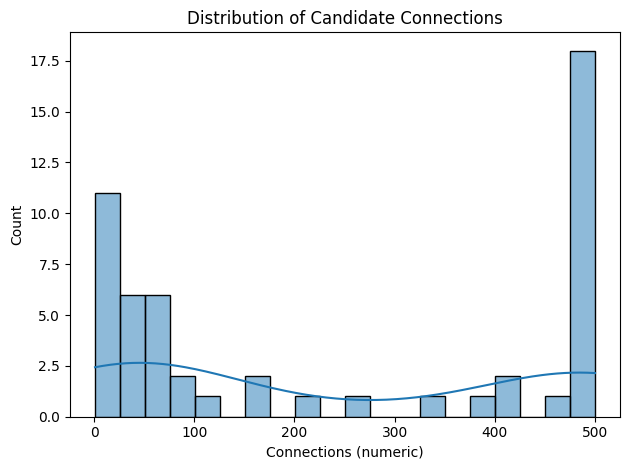

In [27]:
# Univariate analysis

sns.histplot(talents_enc["connection_num"].dropna(), bins=20, kde=True)
plt.title("Distribution of Candidate Connections")
plt.xlabel("Connections (numeric)")
plt.tight_layout()
plt.show()

A large proportion of candidates have 500 or more connections.

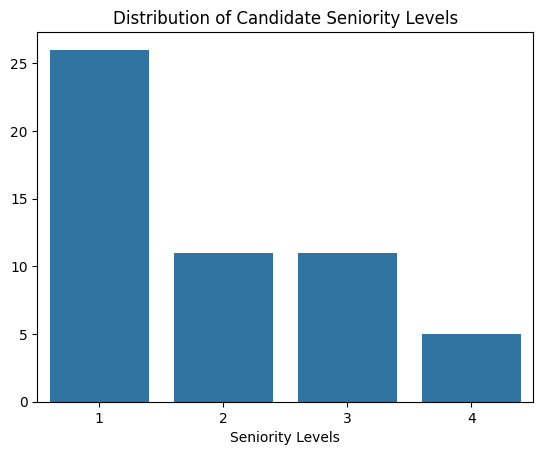

In [29]:
# Explore trends in seniority levels

sen_count = talents_enc["seniority_score"].value_counts()

plt.figure()
sns.barplot(x=sen_count.index, y = sen_count.values)
plt.title("Distribution of Candidate Seniority Levels")
plt.xlabel("Seniority Levels")
plt.show()

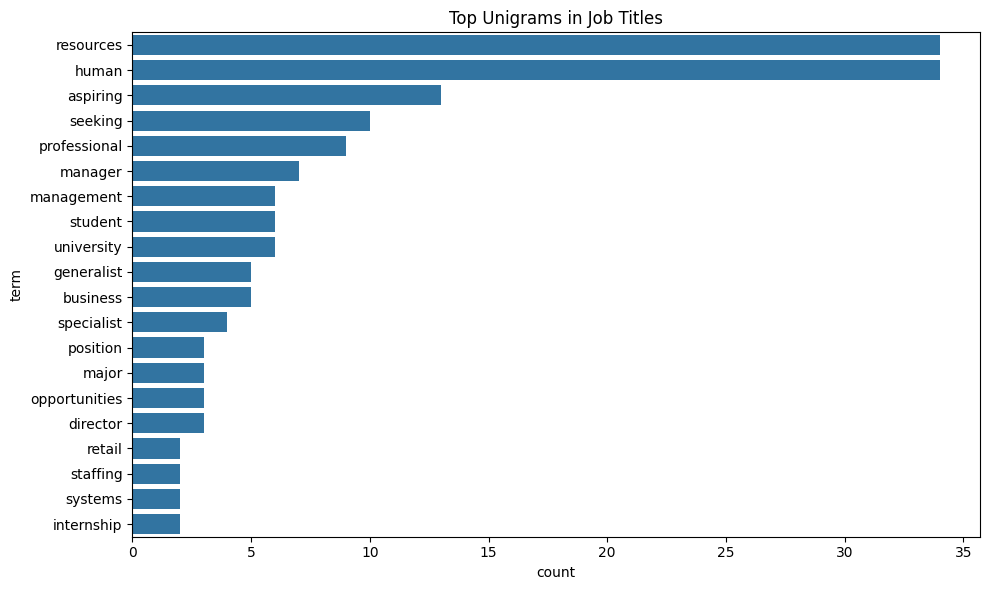

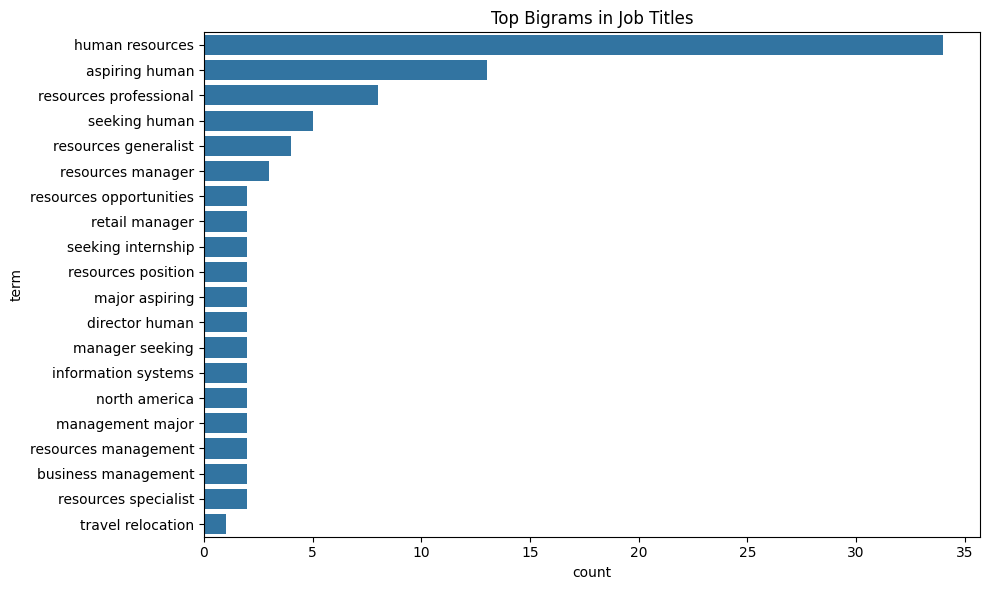

In [30]:
# Text analysis

text_series = talents_enc["job_title"].dropna().astype(str)

for ngram_range, title in [((1, 1), "Top Unigrams in Job Titles"), ((2, 2), "Top Bigrams in Job Titles")]:
    vectorizer = CountVectorizer(stop_words="english", ngram_range=ngram_range, min_df=1)
    X = vectorizer.fit_transform(text_series)
    counts = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(vectorizer.get_feature_names_out())

    top_n = 20
    idx = counts.argsort()[::-1][:top_n]
    top_terms = pd.DataFrame({"term": vocab[idx], "count": counts[idx]})

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_terms, x="count", y="term")
    plt.title(title)
    plt.tight_layout()
    plt.show()

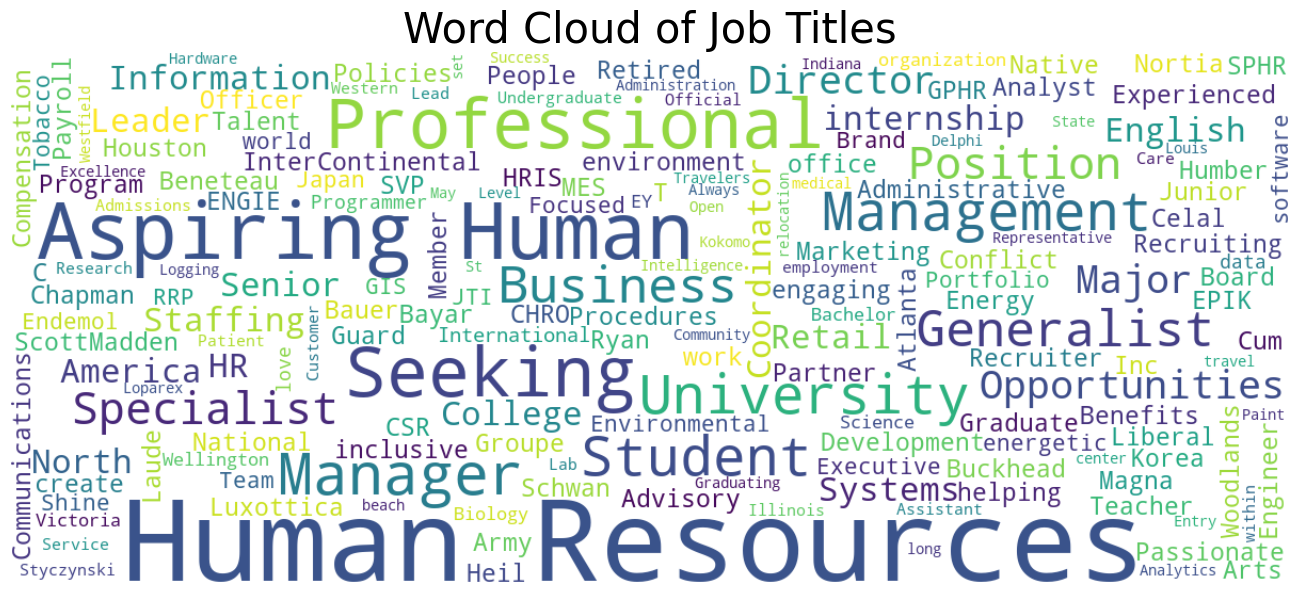

In [31]:
# Generate wordcloud

full_text = " ".join(text_series.tolist())
wordcloud = WordCloud(width=1200, height=500, background_color="white").generate(full_text)
plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Job Titles", size=30)
plt.tight_layout()
plt.show()

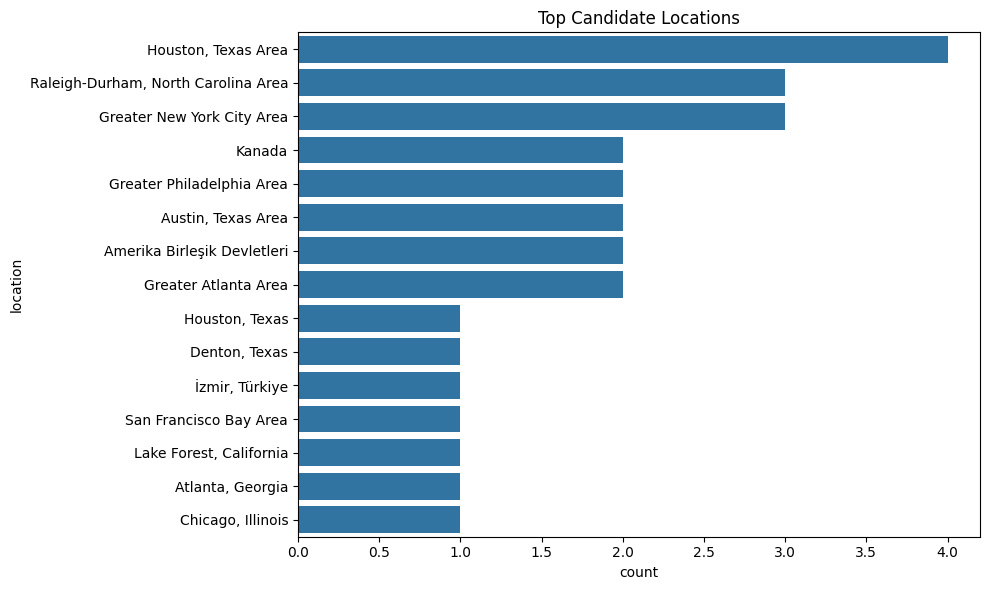

In [32]:
# Explore locations of candidates

top_locations = talents_enc["location"].value_counts().head(15).reset_index()
top_locations.columns = ["location", "count"]

plt.figure(figsize=(10, 6))
sns.barplot(data=top_locations, x="count", y="location")
plt.title("Top Candidate Locations")
plt.tight_layout()
plt.show()

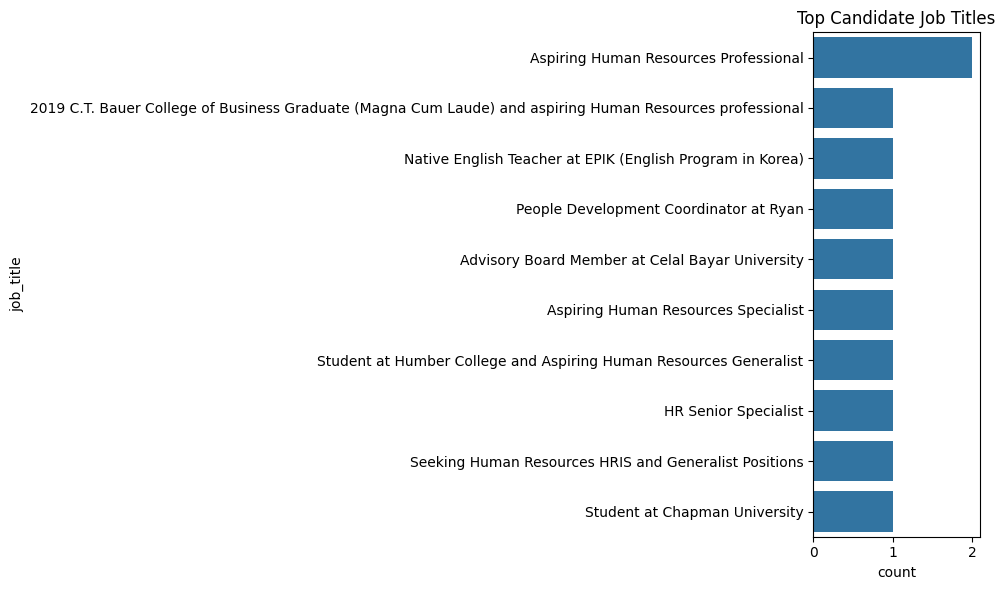

In [33]:
# Explore top job titles

top_titles = talents_enc["job_title"].value_counts().head(10).reset_index()
top_titles.columns = ["job_title", "count"]

plt.figure(figsize=(10, 6))
sns.barplot(data=top_titles, x="count", y="job_title")
plt.title("Top Candidate Job Titles")
plt.tight_layout()
plt.show()

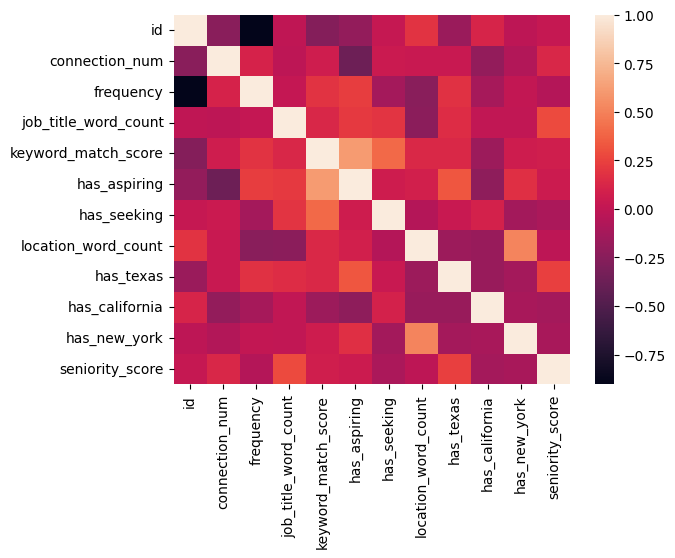

In [34]:
# Correlation in numeric columns

corr = talents_enc.corr(numeric_only=True)
sns.heatmap(corr)
plt.show()

In [35]:
round(corr, 3)

,id,connection_num,frequency,job_title_word_count,keyword_match_score,has_aspiring,has_seeking,location_word_count,has_texas,has_california,has_new_york,seniority_score
id,1.000,-0.244,-0.904,-0.005,-0.270,-0.199,0.023,0.183,-0.172,0.112,-0.018,0.026
connection_num,-0.244,1.000,0.106,-0.014,0.064,-0.371,0.043,0.039,0.035,-0.203,-0.068,0.130
frequency,-0.904,0.106,1.000,0.012,0.186,0.234,-0.125,-0.242,0.179,-0.117,0.006,-0.064
job_title_word_count,-0.005,-0.014,0.012,1.000,0.129,0.216,0.191,-0.236,0.158,-0.004,-0.000,0.280
keyword_match_score,-0.270,0.064,0.186,0.129,1.000,0.609,0.404,0.134,0.135,-0.163,0.058,0.071
has_aspiring,-0.199,-0.371,0.234,0.216,0.609,1.000,0.061,0.080,0.326,-0.222,0.169,0.052
has_seeking,0.023,0.043,-0.125,0.191,0.404,0.061,1.000,-0.060,0.039,0.097,-0.138,-0.096
location_word_count,0.183,0.039,-0.242,-0.236,0.134,0.080,-0.060,1.000,-0.166,-0.182,0.515,-0.017
has_texas,-0.172,0.035,0.179,0.158,0.135,0.326,0.039,-0.166,1.000,-0.176,-0.129,0.236
has_california,0.112,-0.203,-0.117,-0.004,-0.163,-0.222,0.097,-0.182,-0.176,1.000,-0.111,-0.126


Few important obeservations:
1. Keyword match score has a significant positive correlation with terms "aspiring" and "seeking" in the job title.
2. The frequency of candidate appearance in the list is not strongly correlated with any other variable except "id".

In [37]:
# Save EDA output to csv

output_file = "potential_talent_eda_output.csv"
talents_enc.to_csv(output_file, index=False)